## Question 1: Can the foveal neuron activity pattern decode the target cathegory BEFORE the saccade?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import pickle
import aux_functions as aux
importlib.reload(aux)

<module 'aux_functions' from 'e:\\vispred\\aux_functions.py'>

In [2]:
MONKEY = 'M08'
AREA = 'V4'
SESSION = 'm08cat255'

In [3]:
with open(f"session_data\\{SESSION}.pkl", "rb") as file:
    df_session= pickle.load(file)
df_session

,start,search,mapRF,grid_coord,depth,brain_area,sample,array,prefer,SI,RFin,RFout,RF_type,session,neuron_id,coreRFin,
0,847,m08cat255spk033a,m08det254spk033a,-1+5,1186,TE,0.0,NaN,face,0.38549,NaN,NaN,Focal Foveal,m08cat255,spk033a,NaN,NaN
1,848,m08cat255spk033z,m08det254spk033z,-1+5,1186,TE,0.0,NaN,face,0.51208,NaN,NaN,Focal Foveal,m08cat255,spk033z,NaN,NaN
2,849,m08cat255spk034a,m08det254spk034a,-1+5,1346,TE,0.0,NaN,face,0.60449,NaN,NaN,Focal Foveal,m08cat255,spk034a,NaN,NaN
3,850,m08cat255spk034b,m08det254spk034b,-1+5,1346,TE,0.0,NaN,face,1.00000,NaN,NaN,Focal Foveal,m08cat255,spk034b,NaN,NaN
4,851,m08cat255spk034c,m08det254spk034c,-1+5,1346,TE,0.0,0.0,face,0.56654,"0,8,19","1,2,3,4,5,6,7,9,10,11,12,13,14,15,16,17,18,20",Broad Foveal,m08cat255,spk034c,"0,8,19",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,1140,m08cat255spk091b,m08det254spk091b,B+4-4,720,VPA,0.0,0.0,NaN,0.13946,NaN,NaN,Broad Foveal,m08cat255,spk091b,NaN,NaN
227,1141,m08cat255spk091z,m08det254spk091z,B+4-4,720,VPA,NaN,0.0,NaN,NaN,NaN,NaN,Peripheral,m08cat255,spk091z,NaN,NaN
228,1142,m08cat255spk093b,m08det254spk093b,B+4-4,735,VPA,0.0,0.0,NaN,-0.36007,NaN,NaN,Broad Foveal,m08cat255,spk093b,NaN,NaN
229,1143,m08cat255spk095a,m08det254spk095a,B+4-4,750,VPA,NaN,0.0,NaN,NaN,NaN,NaN,Peripheral,m08cat255,spk095a,NaN,NaN


In [4]:
df_session = df_session[df_session['brain_area']==AREA]
df_session

,start,search,mapRF,grid_coord,depth,brain_area,sample,array,prefer,SI,RFin,RFout,RF_type,session,neuron_id,coreRFin,
106,2055,m08cat255spk097z,m08det254spk097z,+3-3,716,V4,0.0,NaN,NaN,-0.285580,NaN,NaN,Focal Foveal,m08cat255,spk097z,NaN,NaN
107,2056,m08cat255spk098a,m08det254spk098a,+3-3,876,V4,0.0,NaN,face,0.108970,NaN,NaN,Focal Foveal,m08cat255,spk098a,NaN,NaN
108,2057,m08cat255spk098b,m08det254spk098b,+3-3,876,V4,0.0,NaN,face,0.176950,NaN,NaN,Focal Foveal,m08cat255,spk098b,NaN,NaN
109,2058,m08cat255spk098z,m08det254spk098z,+3-3,876,V4,0.0,NaN,NaN,0.026967,NaN,NaN,Focal Foveal,m08cat255,spk098z,NaN,NaN
110,2059,m08cat255spk099a,m08det254spk099a,+3-3,726,V4,0.0,NaN,NaN,-0.085379,NaN,NaN,Focal Foveal,m08cat255,spk099a,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,2137,m08cat255spk128a,m08det254spk128a,+3-3,1026,V4,0.0,NaN,face,0.206230,NaN,NaN,Focal Foveal,m08cat255,spk128a,NaN,NaN
189,2138,m08cat255spk128b,m08det254spk128b,+3-3,1026,V4,0.0,NaN,face,0.233680,NaN,NaN,Focal Foveal,m08cat255,spk128b,NaN,NaN
190,2139,m08cat255spk128c,m08det254spk128c,+3-3,1026,V4,0.0,NaN,face,0.690970,NaN,NaN,Focal Foveal,m08cat255,spk128c,NaN,NaN
191,2140,m08cat255spk128d,m08det254spk128d,+3-3,1026,V4,0.0,NaN,face,1.000000,NaN,NaN,Focal Foveal,m08cat255,spk128d,NaN,NaN


In [5]:
path_destiny = f'dados\\{MONKEY}_neurons\\neurons sorted'
list_neuron_ids = df_session['search']
list_prefered_cat = df_session['prefer']
list_brain_area = df_session['brain_area']
list_RF_type = df_session['RF_type']

# OBS: spike times here stop in the END OF THE FIRST FIX!!! We can alter later for posterior analysis.
df_trials = aux.get_df_trials(list_neuron_ids, path_destiny, list(list_prefered_cat), list(list_brain_area), list(list_RF_type), firings_cue_and_array=False)
df_trials

,neuron,prefered,brain_area,RF_type,trial_num,clue_id,clue_cath,imgsacc_id,imgsacc_cath,pre_sacc_time,FP_on,fix_FP,clue_on,clue_off,FP_back,array_on,sacc_start,start_first_fix,end_first_fix,firings
0,m08cat255spk097z,NaN,V4,Focal Foveal,3,1020.0,flower,2030.0,house,0.137433,5.065133,5.152433,5.580300,6.266300,6.266667,6.793967,6.931400,6.947333,7.057100,"[-1.6521999999999997, -1.5935333333333332, -1...."
1,m08cat255spk097z,NaN,V4,Focal Foveal,4,3022.0,face,3022.0,face,0.155533,8.988067,9.227933,9.634067,10.168367,10.168700,10.675167,10.830700,10.832767,11.640533,"[-1.6550333333333338, -1.5921666666666674, -1...."
2,m08cat255spk097z,NaN,V4,Focal Foveal,5,2020.0,house,3005.0,face,0.165867,12.695667,12.698533,13.105633,13.931633,13.932000,14.438333,14.604200,14.607900,14.794833,"[-1.7332, -1.6857333333333333, -1.611033333333..."
3,m08cat255spk097z,NaN,V4,Focal Foveal,7,3019.0,face,1017.0,flower,0.163433,19.097333,19.343733,19.750333,20.874867,20.875200,21.381600,21.545033,21.547100,21.694867,"[-2.4454666666666647, -2.2130666666666663, -2...."
4,m08cat255spk097z,NaN,V4,Focal Foveal,8,2013.0,house,3019.0,face,0.139000,23.554733,23.689867,24.096733,24.610267,24.610633,25.117100,25.256100,25.259900,25.462067,"[-1.5441000000000003, -1.539366666666666, -1.4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150679,m08cat255spk128z,NaN,V4,Focal Foveal,2657,3007.0,face,2024.0,house,0.139367,12806.472433,12806.608333,12807.014333,12807.576533,12807.576900,12808.083233,12808.222600,12808.226200,12808.469667,"[-1.6588333333329501, -1.5046333333320945, -1...."
150680,m08cat255spk128z,NaN,V4,Focal Foveal,2658,2051.0,house,4020.0,hand,0.144167,12810.638433,12810.797333,12811.201200,12811.749333,12811.749700,12812.256100,12812.400267,12812.402700,12812.405467,"[-1.7314333333342802, -1.6982333333344286, -1...."
150681,m08cat255spk128z,NaN,V4,Focal Foveal,2662,3017.0,face,2019.0,house,0.149333,12824.955233,12825.235133,12825.643000,12826.913367,12826.913733,12827.420033,12827.569367,12827.571467,12827.975533,"[-2.538266666666459, -2.440233333332799, -2.42..."
150682,m08cat255spk128z,NaN,V4,Focal Foveal,2663,2050.0,house,2019.0,house,0.122767,12830.079367,12832.670533,12833.072167,12833.800967,12833.801333,12834.307667,12834.430433,12834.437167,12834.572567,"[-4.30256666666719, -4.272266666666837, -4.268..."


## Plotting session details

In [6]:
# complete later with plots of create_tabelao

## Creating the DataFrame to train the model

In [7]:
def get_df_bins_presacc(df_trials, bins, bin_size):
    data_trials_run_model = []
    for trial in df_trials['trial_num'].unique():
        df_this_trial = df_trials[df_trials['trial_num']==trial]
        cat_target = df_this_trial.iloc[0]['imgsacc_cath']
        data_model_row = {'Y':cat_target}
        for index, row in df_this_trial.iterrows():
            neuron_id = row['neuron'][9:]
            firings = np.array(row['firings'])
            counts, _ = np.histogram(firings, bins=bins)
            FR = counts / bin_size
            for i, _ in enumerate(bins[:-1]):
                data_model_row[f'{neuron_id}_Bin{i+1}'] = FR[i]
        data_trials_run_model.append(data_model_row)
    return  pd.DataFrame(data_trials_run_model)

In [ ]:
# bins = np.array([-0.2,-0.15,-0.1,-0.05,0.0])
bins = np.array([-0.4,-0.35,-0.3,-0.25,-0.2,-0.15,-0.1,-0.05,0.0,0.05,0.1,0.15,0.2, 0.25, 0.3])
bin_size = 0.05

df_run_model = get_df_bins_presacc(df_trials, bins, bin_size)
# df_run_model2 = df_run_model[df_run_model['Y'].isin(['house','face'])]
df_run_model

,Y,spk097z_Bin1,spk097z_Bin2,spk097z_Bin3,spk097z_Bin4,spk097z_Bin5,spk097z_Bin6,spk097z_Bin7,spk097z_Bin8,spk097z_Bin9,...,spk128z_Bin5,spk128z_Bin6,spk128z_Bin7,spk128z_Bin8,spk128z_Bin9,spk128z_Bin10,spk128z_Bin11,spk128z_Bin12,spk128z_Bin13,spk128z_Bin14
0,house,20.0,0.0,0.0,20.0,0.0,20.0,0.0,0.0,0.0,...,0.0,0.0,20.0,0.0,0.0,20.0,20.0,0.0,0.0,0.0
1,face,0.0,0.0,0.0,20.0,0.0,0.0,20.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,40.0,20.0,40.0,40.0
2,face,0.0,0.0,40.0,0.0,0.0,20.0,0.0,0.0,40.0,...,20.0,20.0,20.0,0.0,20.0,0.0,60.0,20.0,0.0,0.0
3,flower,0.0,0.0,20.0,20.0,0.0,0.0,0.0,20.0,0.0,...,0.0,20.0,0.0,0.0,0.0,40.0,80.0,0.0,0.0,0.0
4,face,0.0,0.0,0.0,20.0,0.0,20.0,20.0,0.0,20.0,...,20.0,0.0,0.0,20.0,0.0,0.0,40.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1727,house,0.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,20.0,...,0.0,20.0,60.0,20.0,60.0,20.0,40.0,80.0,40.0,0.0
1728,hand,0.0,0.0,0.0,0.0,20.0,0.0,0.0,0.0,20.0,...,20.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1729,house,0.0,0.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0,...,0.0,0.0,40.0,0.0,20.0,100.0,60.0,40.0,40.0,60.0
1730,house,20.0,20.0,0.0,0.0,0.0,0.0,20.0,0.0,0.0,...,20.0,20.0,60.0,20.0,60.0,20.0,60.0,0.0,0.0,0.0


In [9]:
# print(aux.preprocess_spikes(df_trials.iloc[0]['firings']))
# print(aux.preprocess_spikes(df_trials.iloc[0]['firings'],sigma=0))

# print(aux.preprocess_spikes(df_trials.iloc[1]['firings']))
# print(aux.preprocess_spikes(df_trials.iloc[1]['firings'],sigma=0))

In [27]:
def get_df_bins_presacc_smoothing(df_trials, bins, bin_size, sigma=15):
    data_trials_run_model = []
    for trial in df_trials['trial_num'].unique():
        df_this_trial = df_trials[df_trials['trial_num']==trial]
        cat_target = df_this_trial.iloc[0]['imgsacc_cath']
        data_model_row = {'Y':cat_target}
        for index, row in df_this_trial.iterrows():
            neuron_id = row['neuron'][9:]
            firings = np.array(row['firings'])
            FR = aux.preprocess_spikes(firings, sigma=sigma, bin_start=bins[0]*1000, bin_size=bin_size*1000, end_time=bins[-1]*1000)
            for i, _ in enumerate(bins[:-1]):
                data_model_row[f'{neuron_id}_Bin{i+1}'] = FR[i]
        data_trials_run_model.append(data_model_row)
    return  pd.DataFrame(data_trials_run_model)

# bins = np.array([-0.2,-0.15,-0.1,-0.05,0.0])
bins = np.array([-0.4,-0.35,-0.3,-0.25,-0.2,-0.15,-0.1,-0.05,0.0,0.05,0.1,0.15,0.2, 0.25, 0.3])
bin_size = 0.05

df_run_model2 = get_df_bins_presacc_smoothing(df_trials, bins, bin_size, sigma=15)

In [ ]:
# -400 a -200
# MAIN: -200 a 0
# 0 a 200

# 8 tabelas 
# Talvez uma tabelassa seja melhor... Bin -350ms até bin 200ms
# CONFERIR SE MANTEM A ORDEM ENTRE AS 1732
# Separa entre treino e teste (80\20, 5x)
# Normalização por neurnoio (separado treino e teste) (POR TABELA? OU GERAL....)
# TESTAR SE DECODING FUNCIONA EM 0-200s DA SACADA
# HYPERPARAM TUNING COM ESSES DADOS
# TREINAR 8 MODELOS

# pra que serve a validação?

## Machine Learning

In [28]:
# df_run_model
df_run_model2

,Y,spk097z_Bin1,spk097z_Bin2,spk097z_Bin3,spk097z_Bin4,spk097z_Bin5,spk097z_Bin6,spk097z_Bin7,spk097z_Bin8,spk097z_Bin9,...,spk128z_Bin5,spk128z_Bin6,spk128z_Bin7,spk128z_Bin8,spk128z_Bin9,spk128z_Bin10,spk128z_Bin11,spk128z_Bin12,spk128z_Bin13,spk128z_Bin14
0,house,19.800245,0.199755,0.000000,16.655942,3.344021,5.113276,14.881338,0.005423,0.000000,...,23.327502,0.005230,18.495443,1.504557,0.000000,7.050135,30.952994,1.996871,0.000000,0.000000
1,face,0.000000,0.000000,0.000000,17.044871,2.955106,0.000023,15.260898,4.738983,0.000119,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.613601,41.420970,40.817314,28.342610
2,face,0.000000,0.000000,20.618917,19.366307,0.014776,15.765312,4.234605,0.000083,35.171315,...,32.554993,23.059951,3.388506,16.893585,17.407386,2.601630,45.137395,31.517687,3.344893,0.000037
3,flower,0.000000,0.000000,19.962385,19.837860,0.199755,0.000000,0.000000,7.050135,12.946664,...,7.888453,18.006917,1.993670,0.000000,0.000000,33.481667,71.365738,15.151074,0.001521,0.000000
4,face,0.000000,0.000000,0.000000,2.070271,17.918154,19.847103,6.257995,13.902301,10.577958,...,19.504633,0.496769,0.000000,19.941468,0.058532,0.000000,20.097745,19.899225,0.003029,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1727,house,1.735270,0.000000,19.041902,0.958098,0.000000,0.000000,0.000000,0.000000,19.865130,...,1.994257,19.910417,56.061608,18.156959,59.293173,19.407832,44.184483,47.294249,74.135286,1.525485
1728,hand,5.870780,0.000232,0.000000,0.000000,12.118238,7.881175,0.000587,0.000000,19.952980,...,1.733526,21.019210,17.932930,0.011575,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1729,house,0.000000,0.000000,0.000000,0.000000,15.765312,4.234605,0.000083,0.000000,0.000000,...,8.003790,0.000318,19.865130,20.116088,19.995008,61.887477,77.225123,58.763852,40.351682,43.095206
1730,house,13.853509,27.681420,0.200342,0.000000,0.000000,0.000000,18.264730,1.735270,0.000000,...,21.469009,2.117290,49.410442,47.553470,50.498314,13.563486,64.637651,12.264963,0.001402,0.000000


In [ ]:
df_run_model.Y.value_counts()
# df_run_model2.Y.value_counts()

face         657
house        552
flower       288
hand         210
fix_point     25
Name: Y, dtype: int64

In [29]:
# Filtrando apenas as categorias visuais reais
df_run_model = df_run_model[df_run_model['Y'].isin(['face', 'house', 'flower', 'hand'])].copy()
df_run_model2 = df_run_model2[df_run_model2['Y'].isin(['face', 'house', 'flower', 'hand'])].copy()

Iniciando Nested Cross-Validation (5 folds, 14 janelas temporais)...

--- Processando Fold 1/5 ---
Melhor parâmetro C encontrado no pós-sacádico: 0.0012

--- Processando Fold 2/5 ---
Melhor parâmetro C encontrado no pós-sacádico: 0.0009

--- Processando Fold 3/5 ---
Melhor parâmetro C encontrado no pós-sacádico: 0.0012

--- Processando Fold 4/5 ---
Melhor parâmetro C encontrado no pós-sacádico: 0.0009

--- Processando Fold 5/5 ---
Melhor parâmetro C encontrado no pós-sacádico: 0.0019

Processamento concluído com sucesso!


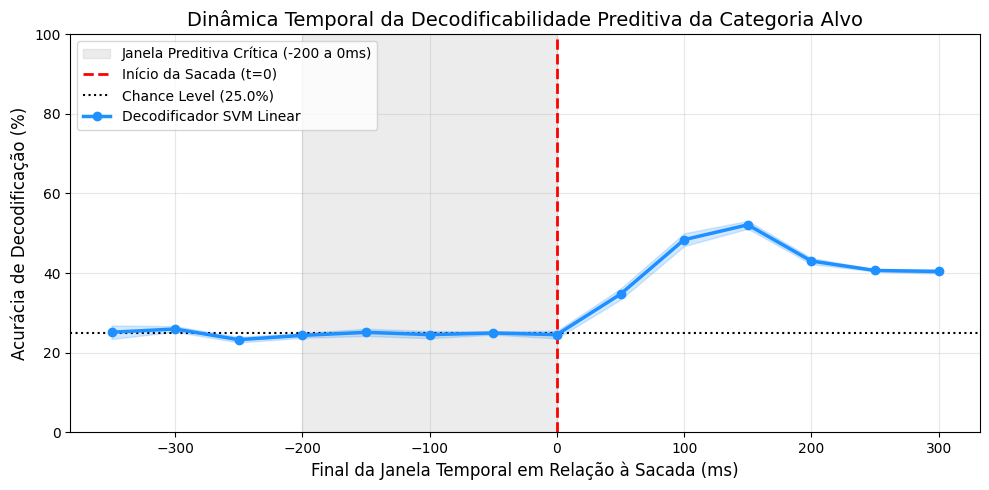

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import loguniform
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score

# ==============================================================================
# 1. FUNÇÃO DE NORMALIZAÇÃO Z-SCORE POR NEURÔNIO (SEM DATA LEAKAGE)
# ==============================================================================
def zscore_per_neuron(X_train, X_test):
    """
    Calcula mu e sigma agregando TODOS os bins de cada neurônio apenas no TREINO,
    e aplica essa padronização no Treino e no Teste.
    """
    X_train_z = X_train.copy()
    X_test_z = X_test.copy()
    
    # Extrai os IDs únicos dos neurônios (ex: 'spk097z' de 'spk097z_Bin1')
    neuron_ids = set([col.split('_Bin')[0] for col in X_train.columns])
    
    for nid in neuron_ids:
        # Seleciona todas as colunas de bins pertencentes a este neurônio
        cols_neuron = [col for col in X_train.columns if col.startswith(f"{nid}_Bin")]
        
        # Pega todos os disparos do neurônio no conjunto de treino (todas as trials x todos os bins)
        train_values = X_train[cols_neuron].values.flatten()
        
        mu = np.mean(train_values)
        sigma = np.std(train_values)
        
        # Evita divisão por zero para neurônios silenciosos
        if sigma == 0:
            sigma = 1e-8
            
        # Aplica z-score no treino e no teste com as métricas do TREINO
        X_train_z[cols_neuron] = (X_train[cols_neuron] - mu) / sigma
        X_test_z[cols_neuron] = (X_test[cols_neuron] - mu) / sigma
        
    return X_train_z, X_test_z

# ==============================================================================
# 2. CONFIGURAÇÃO DAS JANELAS DESLIZANTES (MOVING WINDOWS)
# ==============================================================================
# 14 Bins de 50ms variando de -400ms a +300ms:
# Bin 1: [-400, -350] | ... | Bin 8: [-50, 0] | Bin 9: [0, 50] | ... | Bin 14: [250, 300]
num_bins = 14
# window_size_bins = 4  # 4 bins = 200ms de janela
window_size_bins = 1  # 4 bins = 200ms de janela
num_windows = num_bins - window_size_bins + 1  # 11 janelas no total

# Mapeamento do centro temporal de cada janela (em ms) para o gráfico
# Janela 1 (Bins 1..4): [-400ms a -200ms] -> Centro = -300ms
window_centers = []
for w in range(num_windows):
    win_start_time = -400 + (w * 50)
    win_end_time = win_start_time + (window_size_bins * 50)
    window_centers.append((win_start_time + win_end_time) / 2.0)

# ==============================================================================
# 3. LOOP DE VALIDAÇÃO CRUZADA ANINHADA (NESTED CROSS-VALIDATION)
# ==============================================================================
X = df_run_model.drop(columns=['Y'])
y = df_run_model['Y']

num_folds = 5
outer_cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

# Matriz para guardar as acurácias: Linhas = Folds (5), Colunas = Janelas (11)
fold_accuracies = np.zeros((num_folds, num_windows))

print(f"Iniciando Nested Cross-Validation ({num_folds} folds, {num_windows} janelas temporais)...")

for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    print(f"\n--- Processando Fold {fold_idx + 1}/{num_folds} ---")
    
    # 3.1 Separação de Treino e Teste
    X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # 3.2 Padronização Z-Score por Neurônio
    X_train_z, X_test_z = zscore_per_neuron(X_train_raw, X_test_raw)
    
    # 3.3 Otimização Bayesiana/Randomizada na Janela Pós-Sacádica
    # Seleciona Bins 10 a 13 (+50ms a +250ms) para achar o melhor 'C' do SVM
    post_saccade_cols = [col for col in X_train_z.columns 
                         if any(col.endswith(f"_Bin{b}") for b in [10, 11, 12, 13])]
    
    X_train_post = X_train_z[post_saccade_cols]
    
    # Otimização com amostragem logarítmica para o parâmetro de regularização C
    param_dist = {'C': loguniform(1e-4, 1e2)}
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    search = RandomizedSearchCV(
        estimator=SVC(kernel='linear',class_weight='balanced'),
        param_distributions=param_dist,
        n_iter=15,
        cv=inner_cv,
        scoring='accuracy',
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_train_post, y_train)
    
    best_C = search.best_params_['C']
    print(f"Melhor parâmetro C encontrado no pós-sacádico: {best_C:.4f}")
    
    # 3.4 Treinamento e Avaliação nas Janelas Deslizantes (Moving Windows)
    best_svm = SVC(kernel='linear', class_weight='balanced', C=best_C)
    
    for w_idx in range(num_windows):
        # Seleciona os 4 bins correspondentes à janela atual
        active_bins = [w_idx + 1 + b for b in range(window_size_bins)]
        win_cols = [col for col in X_train_z.columns 
                    if any(col.endswith(f"_Bin{b}") for b in active_bins)]
        
        X_tr_win = X_train_z[win_cols]
        X_te_win = X_test_z[win_cols]
        
        # Treina o modelo com os hiperparâmetros fixos na janela atual do TREINO
        best_svm.fit(X_tr_win, y_train)
        
        # Prevê e calcula a acurácia nos dados de TESTE da mesma janela
        preds = best_svm.predict(X_te_win)
        acc = balanced_accuracy_score(y_test, preds)
        
        fold_accuracies[fold_idx, w_idx] = acc

print("\nProcessamento concluído com sucesso!")

# ==============================================================================
# 4. PLOTAGEM DOS RESULTADOS DE DECODIFICABILIDADE TEMPORAL
# ==============================================================================
mean_acc = np.mean(fold_accuracies, axis=0) * 100  # Converte para %
sem_acc = (np.std(fold_accuracies, axis=0) / np.sqrt(num_folds)) * 100  # Erro Padrão da Média

num_classes = len(np.unique(y))
chance_level = (1.0 / num_classes) * 100

plt.figure(figsize=(10, 5))

# Sombra do período crítico pré-sacádico (-200ms a 0ms)
plt.axvspan(-200, 0, color='gray', alpha=0.15, label='Janela Preditiva Crítica (-200 a 0ms)')

# Marcador da Sacada (t = 0)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Início da Sacada (t=0)')

# Nível do Acaso (Chance Level)
plt.axhline(y=chance_level, color='black', linestyle=':', label=f'Chance Level ({chance_level:.1f}%)')

window_ends = []
for w in range(num_windows):
    win_start_time = -400 + (w * 50)
    win_end_time = win_start_time + (window_size_bins * 50)
    window_ends.append(win_end_time) # Plota onde a janela TERMINA

# Curva Principal de Decodificação (Média +- SEM entre folds)
plt.plot(window_ends, mean_acc, color='dodgerblue', linewidth=2.5, marker='o', label='Decodificador SVM Linear')
plt.fill_between(window_ends, mean_acc - sem_acc, mean_acc + sem_acc, color='dodgerblue', alpha=0.2)

plt.title('Dinâmica Temporal da Decodificabilidade Preditiva da Categoria Alvo', fontsize=14)
plt.xlabel('Final da Janela Temporal em Relação à Sacada (ms)', fontsize=12)
plt.ylabel('Acurácia de Decodificação (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# para cada modelo:
# cross validation 
    # train-test-validation split
    # z-scoring (POR NEURONIO!!!! NAO POR NEURONIO-BIN)
# hyperparam tuning with bayesian search


# PESQUISAR MAIS SOBRE SELECAO DE MODELOS NESSE CONTEXTO | fazer seleção de modelos somente usando os conjuntos com mais de X neurônios? e dps testar em todos
# BIN SHUFFLING (estevao)


# dps de rodar tudo, se nao der nada, ai questione o bin size e etc....
# testar: cortar 10-20ms? por possiveis erros do eye tracker?

In [30]:
import numpy as np
import pandas as pd
from scipy.stats import loguniform
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score

def zscore_per_neuron(X_train, X_test):
    """
    Calcula mu e sigma agregando TODOS os bins de cada neurônio apenas no TREINO,
    e aplica essa padronização no Treino e no Teste.
    """
    X_train_z = X_train.copy()
    X_test_z = X_test.copy()
    
    neuron_ids = set([col.split('_Bin')[0] for col in X_train.columns])
    
    for nid in neuron_ids:
        cols_neuron = [col for col in X_train.columns if col.startswith(f"{nid}_Bin")]
        train_values = X_train[cols_neuron].values.flatten()
        
        mu = np.mean(train_values)
        sigma = np.std(train_values)
        
        if sigma == 0:
            sigma = 1e-8
            
        X_train_z[cols_neuron] = (X_train[cols_neuron] - mu) / sigma
        X_test_z[cols_neuron] = (X_test[cols_neuron] - mu) / sigma
        
    return X_train_z, X_test_z


def run_temporal_decoding(df_run_model, num_bins, window_size_bins, num_folds=5, verbose=True):
    """
    Executa Nested Cross-Validation com SVM Linear e Moving Windows.
    
    Parâmetros:
    -----------
    df_run_model : pd.DataFrame
        DataFrame contendo a coluna target 'Y' e as colunas de spikes 'neuronio_BinX'.
    num_bins : int
        Número total de bins no dataset (ex: 14).
    window_size_bins : int
        Tamanho da janela deslizante em quantidade de bins (ex: 4 para 200ms, 1 para 50ms).
    num_folds : int (default=5)
        Quantidade de folds para o StratifiedKFold externo.
    verbose : bool (default=True)
        Se True, imprime o progresso do treinamento.
        
    Retorna:
    --------
    results : dict
        Dicionário contendo:
        - 'mean_acc': Acurácia média por janela (%)
        - 'sem_acc': Erro padrão da média (%)
        - 'window_centers': Array com os tempos centrais das janelas (ms)
        - 'window_ends': Array com os tempos de término (causais) das janelas (ms)
        - 'chance_level': Nível do acaso teórico baseado no número de classes (%)
        - 'fold_accuracies': Matriz bruta de acurácias (num_folds x num_windows) (%)
    """
    num_windows = num_bins - window_size_bins + 1
    
    # Mapeamento do tempo das janelas (Assumindo bins de 50ms começando em -400ms)
    window_centers = []
    window_ends = []
    for w in range(num_windows):
        win_start_time = -400 + (w * 50)
        win_end_time = win_start_time + (window_size_bins * 50)
        window_centers.append((win_start_time + win_end_time) / 2.0)
        window_ends.append(win_end_time)

    X = df_run_model.drop(columns=['Y'])
    y = df_run_model['Y']
    
    # Nível do acaso com base no número de classes únicas
    num_classes = len(np.unique(y))
    chance_level = (1.0 / num_classes) * 100

    outer_cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
    fold_accuracies = np.zeros((num_folds, num_windows))

    if verbose:
        print(f"Iniciando Decoding Pipeline ({num_folds} folds, {num_windows} janelas temporais)...")

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        if verbose:
            print(f"--- Processando Fold {fold_idx + 1}/{num_folds} ---")
            
        X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # 1. Padronização Causal
        X_train_z, X_test_z = zscore_per_neuron(X_train_raw, X_test_raw)
        
        # 2. Tuning Bayesiano no Pós-Sacádico (Bins 10 a 13)
        post_saccade_cols = [col for col in X_train_z.columns 
                             if any(col.endswith(f"_Bin{b}") for b in [10, 11, 12, 13])]
        X_train_post = X_train_z[post_saccade_cols]
        
        param_dist = {'C': loguniform(1e-4, 1e2)}
        inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        
        search = RandomizedSearchCV(
            estimator=SVC(kernel='linear', class_weight='balanced'),
            param_distributions=param_dist,
            n_iter=15,
            cv=inner_cv,
            scoring='balanced_accuracy',
            random_state=42,
            n_jobs=-1
        )
        search.fit(X_train_post, y_train)
        best_C = search.best_params_['C']
        
        # 3. Treino e Avaliação nas Moving Windows
        best_svm = SVC(kernel='linear', class_weight='balanced', C=best_C)
        
        for w_idx in range(num_windows):
            active_bins = [w_idx + 1 + b for b in range(window_size_bins)]
            win_cols = [col for col in X_train_z.columns 
                        if any(col.endswith(f"_Bin{b}") for b in active_bins)]
            
            X_tr_win = X_train_z[win_cols]
            X_te_win = X_test_z[win_cols]
            
            best_svm.fit(X_tr_win, y_train)
            preds = best_svm.predict(X_te_win)
            acc = balanced_accuracy_score(y_test, preds)
            
            fold_accuracies[fold_idx, w_idx] = acc

    # Prepara métricas para retorno
    mean_acc = np.mean(fold_accuracies, axis=0) * 100
    sem_acc = (np.std(fold_accuracies, axis=0) / np.sqrt(num_folds)) * 100

    return {
        'mean_acc': mean_acc,
        'sem_acc': sem_acc,
        'window_centers': np.array(window_centers),
        'window_ends': np.array(window_ends),
        'chance_level': chance_level,
        'fold_accuracies': fold_accuracies * 100
    }

Iniciando Decoding Pipeline (5 folds, 11 janelas temporais)...
--- Processando Fold 1/5 ---
--- Processando Fold 2/5 ---
--- Processando Fold 3/5 ---
--- Processando Fold 4/5 ---
--- Processando Fold 5/5 ---


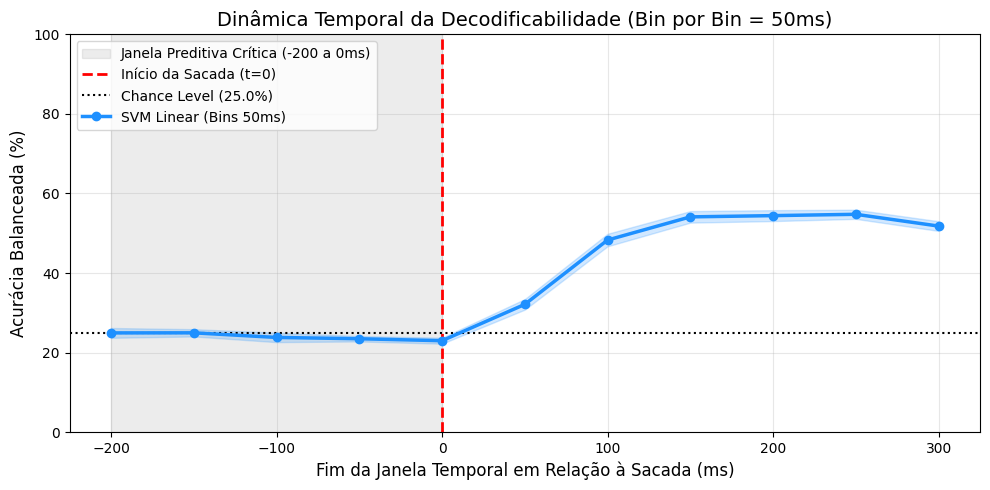

In [32]:
# 1. Executa a função (ex: testando Bins isolados de 50ms)
res0 = run_temporal_decoding(
    df_run_model=df_run_model, 
    num_bins=14, 
    window_size_bins=4
)

# 2. Plot feito totalmente por fora
plt.figure(figsize=(10, 5))

plt.axvspan(-200, 0, color='gray', alpha=0.15, label='Janela Preditiva Crítica (-200 a 0ms)')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Início da Sacada (t=0)')
plt.axhline(y=res0['chance_level'], color='black', linestyle=':', label=f"Chance Level ({res0['chance_level']:.1f}%)")

plt.plot(res0['window_ends'], res0['mean_acc'], color='dodgerblue', linewidth=2.5, marker='o', label='SVM Linear (Bins 50ms)')
plt.fill_between(res0['window_ends'], res0['mean_acc'] - res0['sem_acc'], res0['mean_acc'] + res0['sem_acc'], color='dodgerblue', alpha=0.2)

plt.title('Dinâmica Temporal da Decodificabilidade (Bin por Bin = 50ms)', fontsize=14)
plt.xlabel('Fim da Janela Temporal em Relação à Sacada (ms)', fontsize=12)
plt.ylabel('Acurácia Balanceada (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Iniciando Decoding Pipeline (5 folds, 11 janelas temporais)...
--- Processando Fold 1/5 ---
--- Processando Fold 2/5 ---
--- Processando Fold 3/5 ---
--- Processando Fold 4/5 ---
--- Processando Fold 5/5 ---


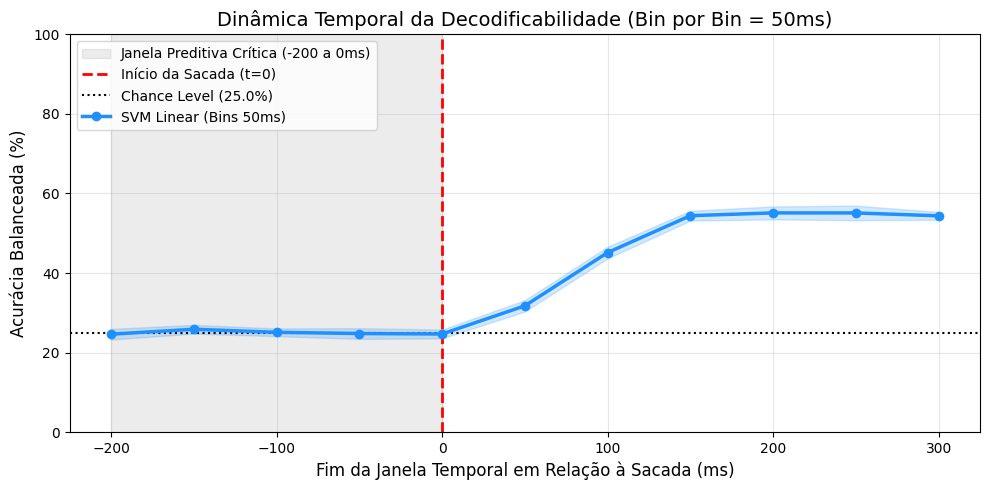

In [31]:
import matplotlib.pyplot as plt

# 1. Executa a função (ex: testando Bins isolados de 50ms)
res = run_temporal_decoding(
    df_run_model=df_run_model2, 
    num_bins=14, 
    window_size_bins=4
)

# 2. Plot feito totalmente por fora
plt.figure(figsize=(10, 5))

plt.axvspan(-200, 0, color='gray', alpha=0.15, label='Janela Preditiva Crítica (-200 a 0ms)')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Início da Sacada (t=0)')
plt.axhline(y=res['chance_level'], color='black', linestyle=':', label=f"Chance Level ({res['chance_level']:.1f}%)")

plt.plot(res['window_ends'], res['mean_acc'], color='dodgerblue', linewidth=2.5, marker='o', label='SVM Linear (Bins 50ms)')
plt.fill_between(res['window_ends'], res['mean_acc'] - res['sem_acc'], res['mean_acc'] + res['sem_acc'], color='dodgerblue', alpha=0.2)

plt.title('Dinâmica Temporal da Decodificabilidade (Bin por Bin = 50ms)', fontsize=14)
plt.xlabel('Fim da Janela Temporal em Relação à Sacada (ms)', fontsize=12)
plt.ylabel('Acurácia Balanceada (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [35]:
import numpy as np
import pandas as pd
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score

# Classificadores
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

def zscore_per_neuron(X_train, X_test):
    X_train_z = X_train.copy()
    X_test_z = X_test.copy()
    neuron_ids = set([col.split('_Bin')[0] for col in X_train.columns])
    
    for nid in neuron_ids:
        cols_neuron = [col for col in X_train.columns if col.startswith(f"{nid}_Bin")]
        train_values = X_train[cols_neuron].values.flatten()
        mu = np.mean(train_values)
        sigma = np.std(train_values) if np.std(train_values) > 0 else 1e-8
        
        X_train_z[cols_neuron] = (X_train[cols_neuron] - mu) / sigma
        X_test_z[cols_neuron] = (X_test[cols_neuron] - mu) / sigma
        
    return X_train_z, X_test_z


def _get_model_config(model_type):
    """Retorna o estimador base e a grade de distribuição de hiperparâmetros."""
    if model_type == 'svm_linear':
        estimator = SVC(kernel='linear', class_weight='balanced')
        param_dist = {'C': loguniform(1e-4, 1e2)}
        
    elif model_type == 'svm_rbf':
        estimator = SVC(kernel='rbf', class_weight='balanced')
        param_dist = {
            'C': loguniform(1e-2, 1e3),
            'gamma': loguniform(1e-4, 1e1)
        }
        
    elif model_type == 'mlp':
        estimator = MLPClassifier(max_iter=500, random_state=42)
        param_dist = {
            'hidden_layer_sizes': [(50,), (100,), (50, 25)],
            'alpha': loguniform(1e-4, 1e-1),
            'learning_rate_init': loguniform(1e-3, 1e-1)
        }
        
    elif model_type == 'lda':
        estimator = LDA(solver='lsqr')
        param_dist = {'shrinkage': uniform(0.0, 1.0)}
        
    elif model_type == 'xgboost':
        estimator = XGBClassifier(eval_metric='mlogloss', random_state=42)
        param_dist = {
            'max_depth': randint(2, 6),
            'learning_rate': loguniform(0.01, 0.3),
            'n_estimators': randint(50, 200)
        }
        
    elif model_type == 'catboost':
        estimator = CatBoostClassifier(auto_class_weights='Balanced', verbose=0, random_state=42)
        param_dist = {
            'depth': randint(3, 7),
            'learning_rate': loguniform(0.01, 0.2),
            'iterations': randint(50, 200)
        }
    else:
        raise ValueError(f"model_type '{model_type}' não suportado.")
        
    return estimator, param_dist


def run_temporal_decoding(df_run_model, num_bins, window_size_bins, model_type='svm_linear', num_folds=5, verbose=True):
    num_windows = num_bins - window_size_bins + 1
    
    window_centers = []
    window_ends = []
    for w in range(num_windows):
        win_start_time = -400 + (w * 50)
        win_end_time = win_start_time + (window_size_bins * 50)
        window_centers.append((win_start_time + win_end_time) / 2.0)
        window_ends.append(win_end_time)

    X = df_run_model.drop(columns=['Y'])
    
    # Codificação dos rótulos para garantir compatibilidade com XGBoost/CatBoost
    le = LabelEncoder()
    y = le.fit_transform(df_run_model['Y'])
    
    num_classes = len(np.unique(y))
    chance_level = (1.0 / num_classes) * 100

    outer_cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
    fold_accuracies = np.zeros((num_folds, num_windows))

    if verbose:
        print(f"\n==================================================")
        print(f"Executando Pipeline para Modelo: [{model_type.upper()}]")
        print(f"==================================================")

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        if verbose:
            print(f"--- Fold {fold_idx + 1}/{num_folds} ---")
            
        X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # 1. Z-Score Causal
        X_train_z, X_test_z = zscore_per_neuron(X_train_raw, X_test_raw)
        
        # 2. Tuning na Janela Pós-Sacádica (Bins 10 a 13)
        post_saccade_cols = [col for col in X_train_z.columns 
                             if any(col.endswith(f"_Bin{b}") for b in [10, 11, 12, 13])]
        X_train_post = X_train_z[post_saccade_cols]
        
        base_estimator, param_dist = _get_model_config(model_type)
        inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        
        search = RandomizedSearchCV(
            estimator=base_estimator,
            param_distributions=param_dist,
            n_iter=10,
            cv=inner_cv,
            scoring='balanced_accuracy',
            random_state=42,
            n_jobs=-1
        )
        search.fit(X_train_post, y_train)
        
        # 3. Treino e Avaliação nas Moving Windows com os Melhores Hiperparâmetros
        best_model = search.best_estimator_
        
        for w_idx in range(num_windows):
            active_bins = [w_idx + 1 + b for b in range(window_size_bins)]
            win_cols = [col for col in X_train_z.columns 
                        if any(col.endswith(f"_Bin{b}") for b in active_bins)]
            
            X_tr_win = X_train_z[win_cols]
            X_te_win = X_test_z[win_cols]
            
            best_model.fit(X_tr_win, y_train)
            preds = best_model.predict(X_te_win)
            acc = balanced_accuracy_score(y_test, preds)
            
            fold_accuracies[fold_idx, w_idx] = acc

    mean_acc = np.mean(fold_accuracies, axis=0) * 100
    sem_acc = (np.std(fold_accuracies, axis=0) / np.sqrt(num_folds)) * 100

    return {
        'model_type': model_type,
        'mean_acc': mean_acc,
        'sem_acc': sem_acc,
        'window_centers': np.array(window_centers),
        'window_ends': np.array(window_ends),
        'chance_level': chance_level,
        'fold_accuracies': fold_accuracies * 100
    }


Executando Pipeline para Modelo: [SVM_LINEAR]
--- Fold 1/5 ---
--- Fold 2/5 ---
--- Fold 3/5 ---
--- Fold 4/5 ---
--- Fold 5/5 ---

Executando Pipeline para Modelo: [SVM_RBF]
--- Fold 1/5 ---
--- Fold 2/5 ---
--- Fold 3/5 ---
--- Fold 4/5 ---
--- Fold 5/5 ---

Executando Pipeline para Modelo: [LDA]
--- Fold 1/5 ---
--- Fold 2/5 ---
--- Fold 3/5 ---
--- Fold 4/5 ---
--- Fold 5/5 ---

Executando Pipeline para Modelo: [MLP]
--- Fold 1/5 ---


c:\Users\lpdon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


--- Fold 2/5 ---
--- Fold 3/5 ---


c:\Users\lpdon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


--- Fold 4/5 ---
--- Fold 5/5 ---

Executando Pipeline para Modelo: [XGBOOST]
--- Fold 1/5 ---
--- Fold 2/5 ---
--- Fold 3/5 ---
--- Fold 4/5 ---
--- Fold 5/5 ---

Executando Pipeline para Modelo: [CATBOOST]
--- Fold 1/5 ---


c:\Users\lpdon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
7 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
7 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\lpdon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\lpdon\AppData\Local\Programs\Python\Python311\Lib\site-packages\catboost\core.py", line 5547, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use

--- Fold 2/5 ---
--- Fold 3/5 ---
--- Fold 4/5 ---
--- Fold 5/5 ---


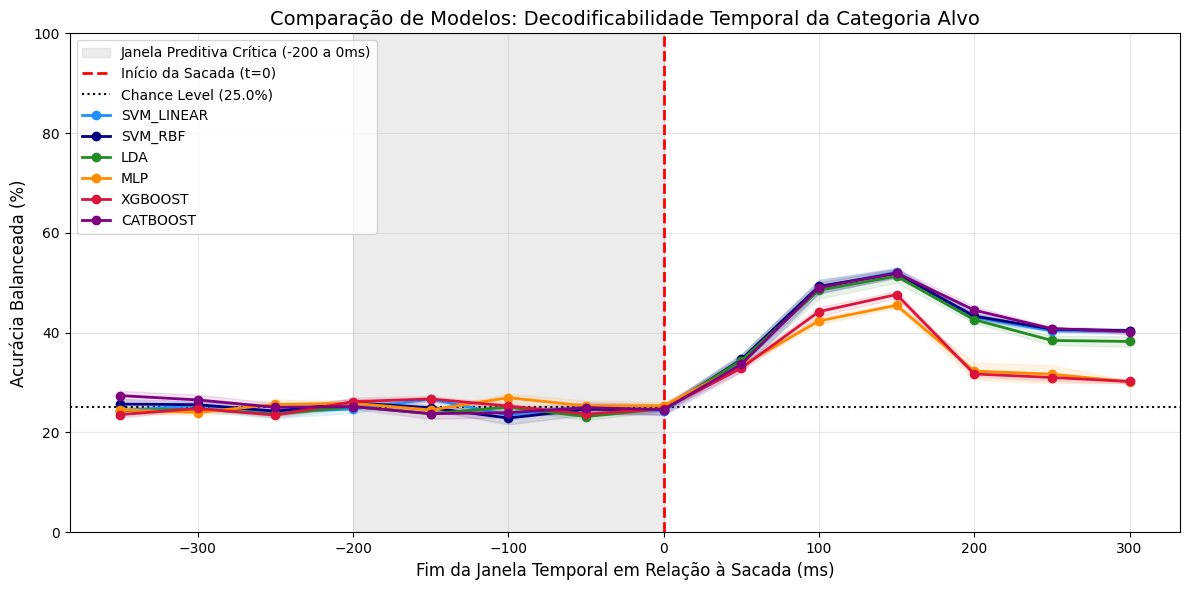

In [36]:
import matplotlib.pyplot as plt

# Lista dos modelos que você quer testar
models_to_test = ['svm_linear', 'svm_rbf', 'lda', 'mlp', 'xgboost', 'catboost']

# Dicionário para guardar todos os outputs
results_dict = {}

# Executa para cada modelo
for m in models_to_test:
    results_dict[m] = run_temporal_decoding(
        df_run_model=df_run_model,
        num_bins=14,
        window_size_bins=1, # Testando Bins de 50ms isolados
        model_type=m,
        num_folds=5,
        verbose=True
    )

# ==============================================================================
# PLOT COMPARATIVO MULTI-MODELO
# ==============================================================================
plt.figure(figsize=(12, 6))

plt.axvspan(-200, 0, color='gray', alpha=0.15, label='Janela Preditiva Crítica (-200 a 0ms)')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Início da Sacada (t=0)')

# Linha do Acaso (pega do primeiro resultado)
chance_val = list(results_dict.values())[0]['chance_level']
plt.axhline(y=chance_val, color='black', linestyle=':', label=f'Chance Level ({chance_val:.1f}%)')

# Paleta de cores para os modelos
colors = {
    'svm_linear': 'dodgerblue',
    'svm_rbf': 'navy',
    'lda': 'forestgreen',
    'mlp': 'darkorange',
    'xgboost': 'crimson',
    'catboost': 'purple'
}

for m in models_to_test:
    res = results_dict[m]
    plt.plot(
        res['window_ends'], 
        res['mean_acc'], 
        label=m.upper(), 
        color=colors.get(m, 'black'), 
        linewidth=2, 
        marker='o'
    )
    # Sombra leve de erro padrão
    plt.fill_between(
        res['window_ends'], 
        res['mean_acc'] - res['sem_acc'], 
        res['mean_acc'] + res['sem_acc'], 
        color=colors.get(m, 'black'), 
        alpha=0.1
    )

plt.title('Comparação de Modelos: Decodificabilidade Temporal da Categoria Alvo', fontsize=14)
plt.xlabel('Fim da Janela Temporal em Relação à Sacada (ms)', fontsize=12)
plt.ylabel('Acurácia Balanceada (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()